In [17]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
if torch.cuda.is_available():
    print("gpu available")
    print(f"using gpu: {torch.cuda.get_device_name(0)}")

gpu available
using gpu: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [26]:
data_df = pd.read_csv("riceClassification.csv")

In [27]:
data_df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [28]:
data_df.shape

(18185, 12)

## DATA PREPROCESSING

In [29]:
data_df.dropna(inplace = True)
data_df.drop(['id'],axis = 1, inplace = True)
print(data_df.shape)
original_df = data_df.copy()

(18185, 11)


In [30]:
# normalisation
for column in data_df.columns:
    data_df[column] = data_df[column]/data_df[column].abs().max()
data_df.head()


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [37]:
X = np.array(data_df.iloc[:,:-1]) # taking all the rows and columns except the last one
y = np.array(data_df.iloc[:,-1]) # taking all the rows and the last column

In [39]:
y.shape, X.shape

((18185,), (18185, 10))

In [41]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.3)   

In [42]:
X_test,X_val,y_test,y_val = train_test_split(X_test,y_test,test_size = 0.5)

In [44]:
class dataset(Dataset):
    def __init__(self,inputs,output):
        self.inputs = torch.tensor(inputs,dtype = torch.float32).to(device)
        self.output = torch.tensor(output,dtype = torch.float32).to(device)
    def __len__(self):
        return len(self.inputs)
    def __getitem__(self,index):
        return self.inputs[index],self.output[index]
    

In [45]:
training_data = dataset(X_train,y_train)
validation_data = dataset(X_val,y_val)
testing_data = dataset(X_test,y_test)

In [98]:
train_dataloader = DataLoader(training_data,batch_size = 1024, shuffle = True,pin_memory=False,num_workers=0)
val_dataloader = DataLoader(validation_data,batch_size = 1024, shuffle = True,pin_memory=False,num_workers=0)
test_dataloader = DataLoader(testing_data,batch_size = 1024, shuffle = True,pin_memory=False,num_workers=0)

In [99]:
for x,y in train_dataloader:
    print(x)
    print(y)
    break


tensor([[0.8854, 0.9231, 0.8364,  ..., 0.7800, 0.7981, 0.6262],
        [0.6579, 0.7855, 0.7471,  ..., 0.6947, 0.7475, 0.5965],
        [0.3563, 0.5663, 0.5483,  ..., 0.4765, 0.8607, 0.5860],
        ...,
        [0.6751, 0.8940, 0.6653,  ..., 0.7165, 0.7212, 0.7623],
        [0.5955, 0.8642, 0.6086,  ..., 0.6897, 0.6866, 0.8055],
        [0.8857, 0.8603, 0.9034,  ..., 0.7604, 0.8402, 0.5403]],
       device='cuda:0')
tensor([0., 1., 1.,  ..., 1., 1., 0.], device='cuda:0')


In [100]:
class MyModel(nn.Module):
    def __init__(self,input_dim):
        super(MyModel,self).__init__()
        self.input_layer = nn.Linear(input_dim.shape[1],20)
        self.linear = nn.Linear(20,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, inputs):
        inputs = self.input_layer(inputs)
        inputs = self.linear(inputs)
        inputs = self.sigmoid(inputs)
        return inputs
        
        

In [101]:
model = MyModel(X_train).to(device)

In [102]:
summary(model,(X_train.shape[1],))

Layer (type:depth-idx)                   Output Shape              Param #
├─Linear: 1-1                            [-1, 20]                  220
├─Linear: 1-2                            [-1, 1]                   21
├─Sigmoid: 1-3                           [-1, 1]                   --
Total params: 241
Trainable params: 241
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00


Layer (type:depth-idx)                   Output Shape              Param #
├─Linear: 1-1                            [-1, 20]                  220
├─Linear: 1-2                            [-1, 1]                   21
├─Sigmoid: 1-3                           [-1, 1]                   --
Total params: 241
Trainable params: 241
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [103]:
#loss fxn

criterion = nn.BCELoss()
optimizer = Adam(model.parameters(),lr = 1e-3)


In [104]:
#training

total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

In [109]:
epochs = 10
for epoch in range(epochs):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_val = 0

    for data in train_dataloader:
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        prediction = model(inputs).squeeze(1)
        
        batch_loss = criterion(prediction, labels)

        total_loss_train += batch_loss.item()

        acc = ((prediction).round() == labels).sum().item()
        total_acc_train += acc

        batch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    with torch.no_grad():
        for data in val_dataloader:
            inputs,labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            prediction = model(inputs).squeeze(1)

            batch_loss = criterion(prediction, labels)

            total_loss_val += batch_loss.item()

            acc = ((prediction).round() == labels).sum().item()
            total_acc_val += acc
    total_loss_train_plot.append(round(total_loss_train/1000,4))
    total_loss_validation_plot.append(round(total_loss_val/1000,4))
    
    total_acc_train_plot.append(round(total_acc_train/training_data.__len__() * 100,4))
    total_acc_validation_plot.append(round(total_acc_val/validation_data.__len__() * 100,4))

    print(f'''Epoch no. {epoch + 1} Train Loss : {round(total_loss_train/1000, 4)} Train Accuracy {round(total_acc_train/training_data.__len__() * 100,4)}
              Validation Loss: {round(total_loss_val/1000,4)} Validation Accuracy : {round(total_acc_val/validation_data.__len__() * 100,4)}''')
    
    print("="*25)        
    
    
     
        
                                  
        
    

Epoch no. 1 Train Loss : 0.0008 Train Accuracy 98.7037
              Validation Loss: 0.0002 Validation Accuracy : 98.3504
Epoch no. 2 Train Loss : 0.0007 Train Accuracy 98.7037
              Validation Loss: 0.0002 Validation Accuracy : 98.3504
Epoch no. 3 Train Loss : 0.0007 Train Accuracy 98.6488
              Validation Loss: 0.0002 Validation Accuracy : 98.3504
Epoch no. 4 Train Loss : 0.0007 Train Accuracy 98.6566
              Validation Loss: 0.0002 Validation Accuracy : 98.4238
Epoch no. 5 Train Loss : 0.0007 Train Accuracy 98.6409
              Validation Loss: 0.0002 Validation Accuracy : 98.3871
Epoch no. 6 Train Loss : 0.0007 Train Accuracy 98.6802
              Validation Loss: 0.0002 Validation Accuracy : 98.4238
Epoch no. 7 Train Loss : 0.0007 Train Accuracy 98.6723
              Validation Loss: 0.0002 Validation Accuracy : 98.3871
Epoch no. 8 Train Loss : 0.0007 Train Accuracy 98.6488
              Validation Loss: 0.0002 Validation Accuracy : 98.4238
Epoch no. 9 Trai

In [113]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0
    for data in test_dataloader:
        inputs, labels = data

        prediction = model(inputs).squeeze(1)

        batch_loss_test = criterion(prediction,labels).item()

        total_loss_test += batch_loss_test

        acc = ((prediction).round() == labels).sum().item()
        total_acc_test += acc
        
print("Accuracy: ", round(total_acc_test/testing_data.__len__() * 100 , 4))
    

Accuracy:  98.6804


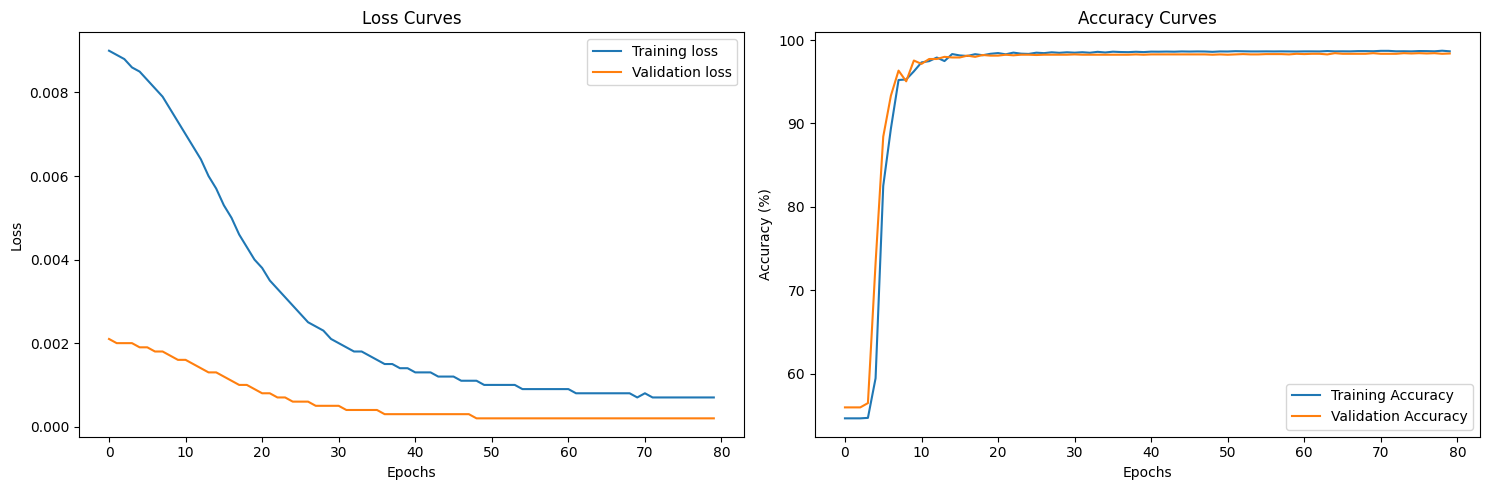

In [123]:
# 1. Initialize the layout explicitly
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# 2. Draw on the first subplot (Loss)
axs[0].plot(total_loss_train_plot, label="Training loss")
axs[0].plot(total_loss_validation_plot, label="Validation loss")
axs[0].set_title("Loss Curves")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].legend()

# 3. Draw on the second subplot (Accuracy)
axs[1].plot(total_acc_train_plot, label="Training Accuracy")
axs[1].plot(total_acc_validation_plot, label="Validation Accuracy")
axs[1].set_title("Accuracy Curves")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy (%)")
axs[1].legend()

# 4. Display the figure cleanly
plt.tight_layout()
plt.show()